## **JAMBOREE : IVY LEAGUE COLLEGE ADMISSION PREDICTION**

### **Objective:**

Predict chance of admission using

1. Linear Regression
2. Understand how different factors like
GRE Scores, TOEFL Scores, CGPA, University Rating etc help in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves
3. Build a model that helps in predict one's chances of admission given the rest of the variables.
4. Generate actionable insights and recommendations for model improvement.

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


In [2]:
# Loading the dataset and viewing first 5 rows

df = pd.read_csv("/content/Jamboree_Admission.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [10]:
# checking shape of the dataset-- no.of rows & columns
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 500
Columns : 9


In [11]:
# checking column names
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [12]:
# removing white spaces from column names (LOR,Chance of Admit has white spaces)
df.columns = df.columns.str.strip()

In [13]:
# checking datatypes and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [14]:
# statistical summary
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


After loading and exploring the dataset, we gain
a clear understanding of the structure
and components of the data. The dataset contains multiple features that influence the chance of admit including both integer variables (such as **GRE Score, TOEFL Score, Unversity Rating, Research**) and float variables(**SOP, LOR, CGPA**).

The **'University Rating'** & **'Research'** columns are to be qualified as category datatype

  --> University Rating - 1 to 5

  --> Research - 0 & 1

The target variable in this dataset is **Chance of Admit**,
which is a continuous numerical value ranging from 0 to 1 like probabilities.

This confirms that the problem is a **regression problem**, where the goal is to predict a numeric outcome.

By looking at the features, we can infer that Chance of Admit is influenced by multiple real-world factors such as TOEFL Score, University rating, LOR, SOP etc. This suggests
that **Multiple Linear Regression** will be more appropriate than Simple Linear Regression
for this problem.



In [15]:
#Removing 'Serial No' column because we do not want our model to learn anything from this irrelevant feature!
df=df.loc[:,'GRE Score':]
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [16]:
# checking duplicate values
print(f" there are {df.duplicated().sum()} duplicate rows in this dataset")

 there are 0 duplicate rows in this dataset


In [17]:
# checking unique values in each column
for col in df.columns:
  print(col)
  print(df[col].unique())
  print()

GRE Score
[337 324 316 322 314 330 321 308 302 323 325 327 328 307 311 317 319 318
 303 312 334 336 340 298 295 310 300 338 331 320 299 304 313 332 326 329
 339 309 315 301 296 294 306 305 290 335 333 297 293]

TOEFL Score
[118 107 104 110 103 115 109 101 102 108 106 111 112 105 114 116 119 120
  98  93  99  97 117 113 100  95  96  94  92]

University Rating
[4 3 2 5 1]

SOP
[4.5 4.  3.  3.5 2.  5.  1.5 1.  2.5]

LOR
[4.5 3.5 2.5 3.  4.  1.5 2.  5.  1. ]

CGPA
[9.65 8.87 8.   8.67 8.21 9.34 8.2  7.9  8.6  8.4  9.   9.1  8.3  8.7
 8.8  8.5  9.5  9.7  9.8  9.6  7.5  7.2  7.3  8.1  9.4  9.2  7.8  7.7
 9.3  8.85 7.4  7.6  6.8  8.92 9.02 8.64 9.22 9.16 9.64 9.76 9.45 9.04
 8.9  8.56 8.72 8.22 7.54 7.36 8.02 9.36 8.66 8.42 8.28 8.14 8.76 7.92
 7.66 8.03 7.88 7.84 8.96 9.24 8.88 8.46 8.12 8.25 8.47 9.05 8.78 9.18
 9.46 9.38 8.48 8.68 8.34 8.45 8.62 7.46 7.28 8.84 9.56 9.48 8.36 9.32
 8.71 9.35 8.65 9.28 8.77 8.16 9.08 9.12 9.15 9.44 9.92 9.11 8.26 9.43
 9.06 8.75 8.89 8.69 7.86 9.01 8.97 8.33

**University Rating, Research, SOP and LOR** are features with ordinal values. Since they are already in integer anf float format, it works fine for machine learning models.

<Axes: >

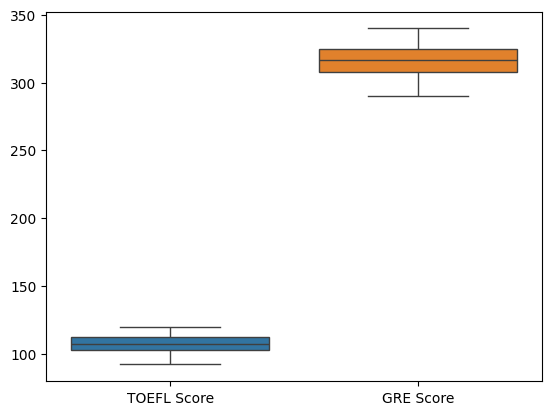

In [18]:
# checking the distribution & outliers in features with larger units seperately

sns.boxplot((df['TOEFL Score'],df['GRE Score']))

<Axes: >

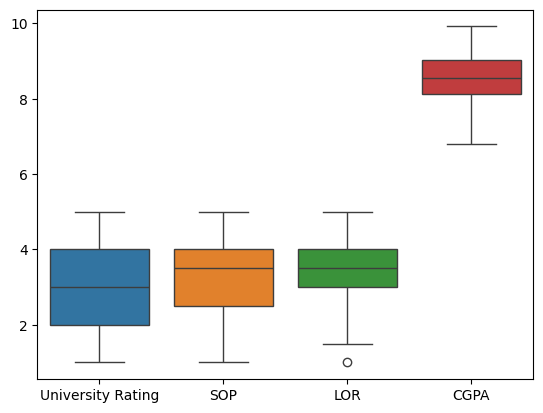

In [19]:
# remaining features except 'Research'
sns.boxplot(df.iloc[:,2:6])

Most of the features have no outliers except a single outlier in the LOR(letter of recommendation) feature

In [20]:
# identifying the outlier to check whether its legitimate outlier or typo
df.loc[df['LOR'].idxmin()]

,347
GRE Score,299.00
TOEFL Score,94.00
University Rating,1.00
SOP,1.00
LOR,1.00
CGPA,7.34
Research,0.00
Chance of Admit,0.42


the outlier is in index 347

A single outlier  can affect the regression as we have very less data points and our loss function **MSE(Mean Squared Error)** is sensitive to outliers.

Since MSE squares differences, outliers can disproportionately affect the overall error metric, leading to ***potential overfitting*** to outlier observations and misrepresentations of the model’s performance on typical data points.

However in the above case, it seems as a ***"legitimate extreme"*** because looking at other features like University Rating, CGPA, TOEFL Score and GRE Score (all low), the chance of Admit is 0.42 which is near to the minimum value

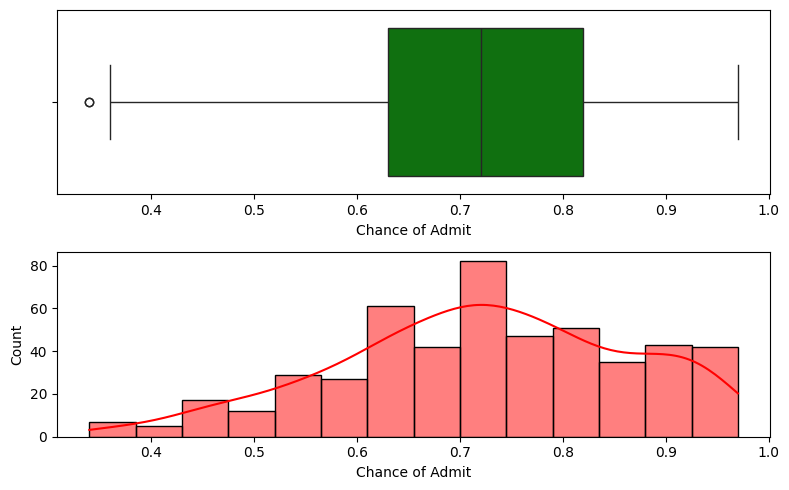

In [21]:
# checking the distribution of target variable
plt.figure(figsize=(8,5))

plt.subplot(2, 1, 1)
sns.boxplot(x=df['Chance of Admit'],color='g')

plt.subplot(2,1,2)
sns.histplot(df['Chance of Admit'],kde=True,color='r')

plt.tight_layout()
plt.show()

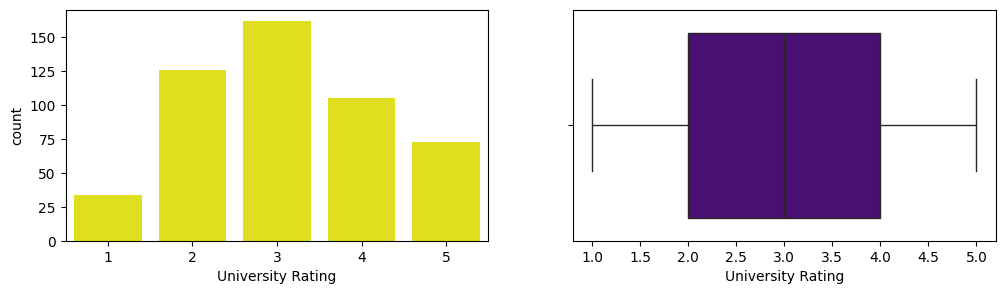

In [22]:
# count & distribution of variables with ordinal values
plt.figure(figsize=(12,3))
plt.subplot(1,2,1)
sns.countplot(x=df['University Rating'],color='yellow')
plt.subplot(1,2,2)
sns.boxplot(x=df['University Rating'],color='indigo')

plt.show()

Most of the universities has a rating of 3 (mid-tier) followed by 2 and there no outliers in this feature.

Box plot reveals that the University Ratings are approximate normally distributed

In [23]:
# frequency count
df['Research'].value_counts()

,count
Research,
1,280
0,220


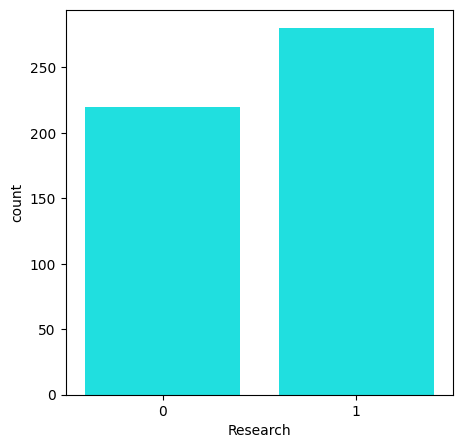

In [24]:
# checking the count of students with research experience (0- no experience, 1-has experience)
plt.figure(figsize=(5,5))
sns.countplot(x=df['Research'],color='cyan')
plt.show()

220 students has no research experience and rest 280 students has research experience

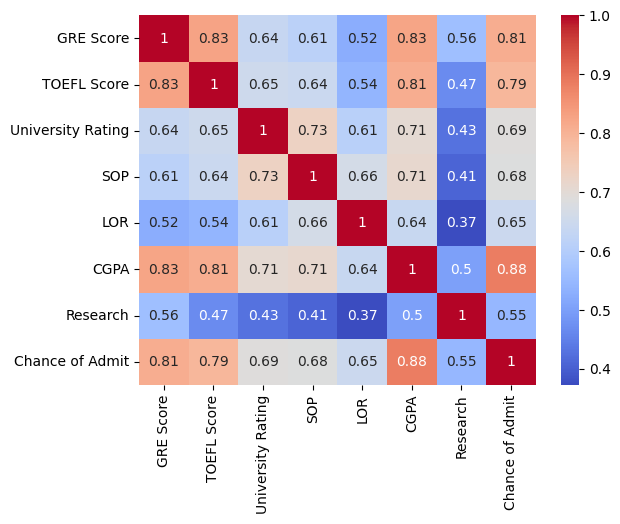

In [25]:
# Correlation analysis

numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [26]:
# Displaying features and their correlation with target variable
top_features = df.corr()['Chance of Admit'].sort_values(ascending=False)
print(top_features[1:])

CGPA                 0.882413
GRE Score            0.810351
TOEFL Score          0.792228
University Rating    0.690132
SOP                  0.684137
LOR                  0.645365
Research             0.545871
Name: Chance of Admit, dtype: float64


Based on correlation values, CGPA is the strongest predictor of the target ("Chance of Admit"), followed closely by GRE and TOEFL scores.
Since all these features have a ***positive correlation*** with the target, they are good candidates for a linear regression model.

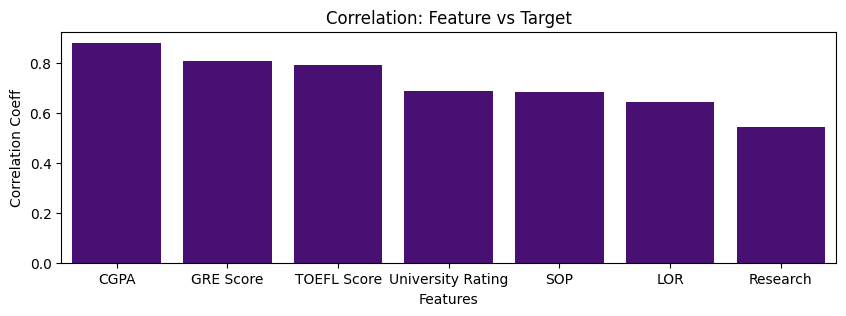

In [30]:
# plotting  correlation of features with target
plt.figure(figsize=(10,3))
sns.barplot(x=top_features[1:].index,y=top_features[1:].values,color = 'indigo')
plt.xlabel('Features')
plt.ylabel('Correlation Coeff')
plt.title('Correlation: Feature vs Target')

plt.show()

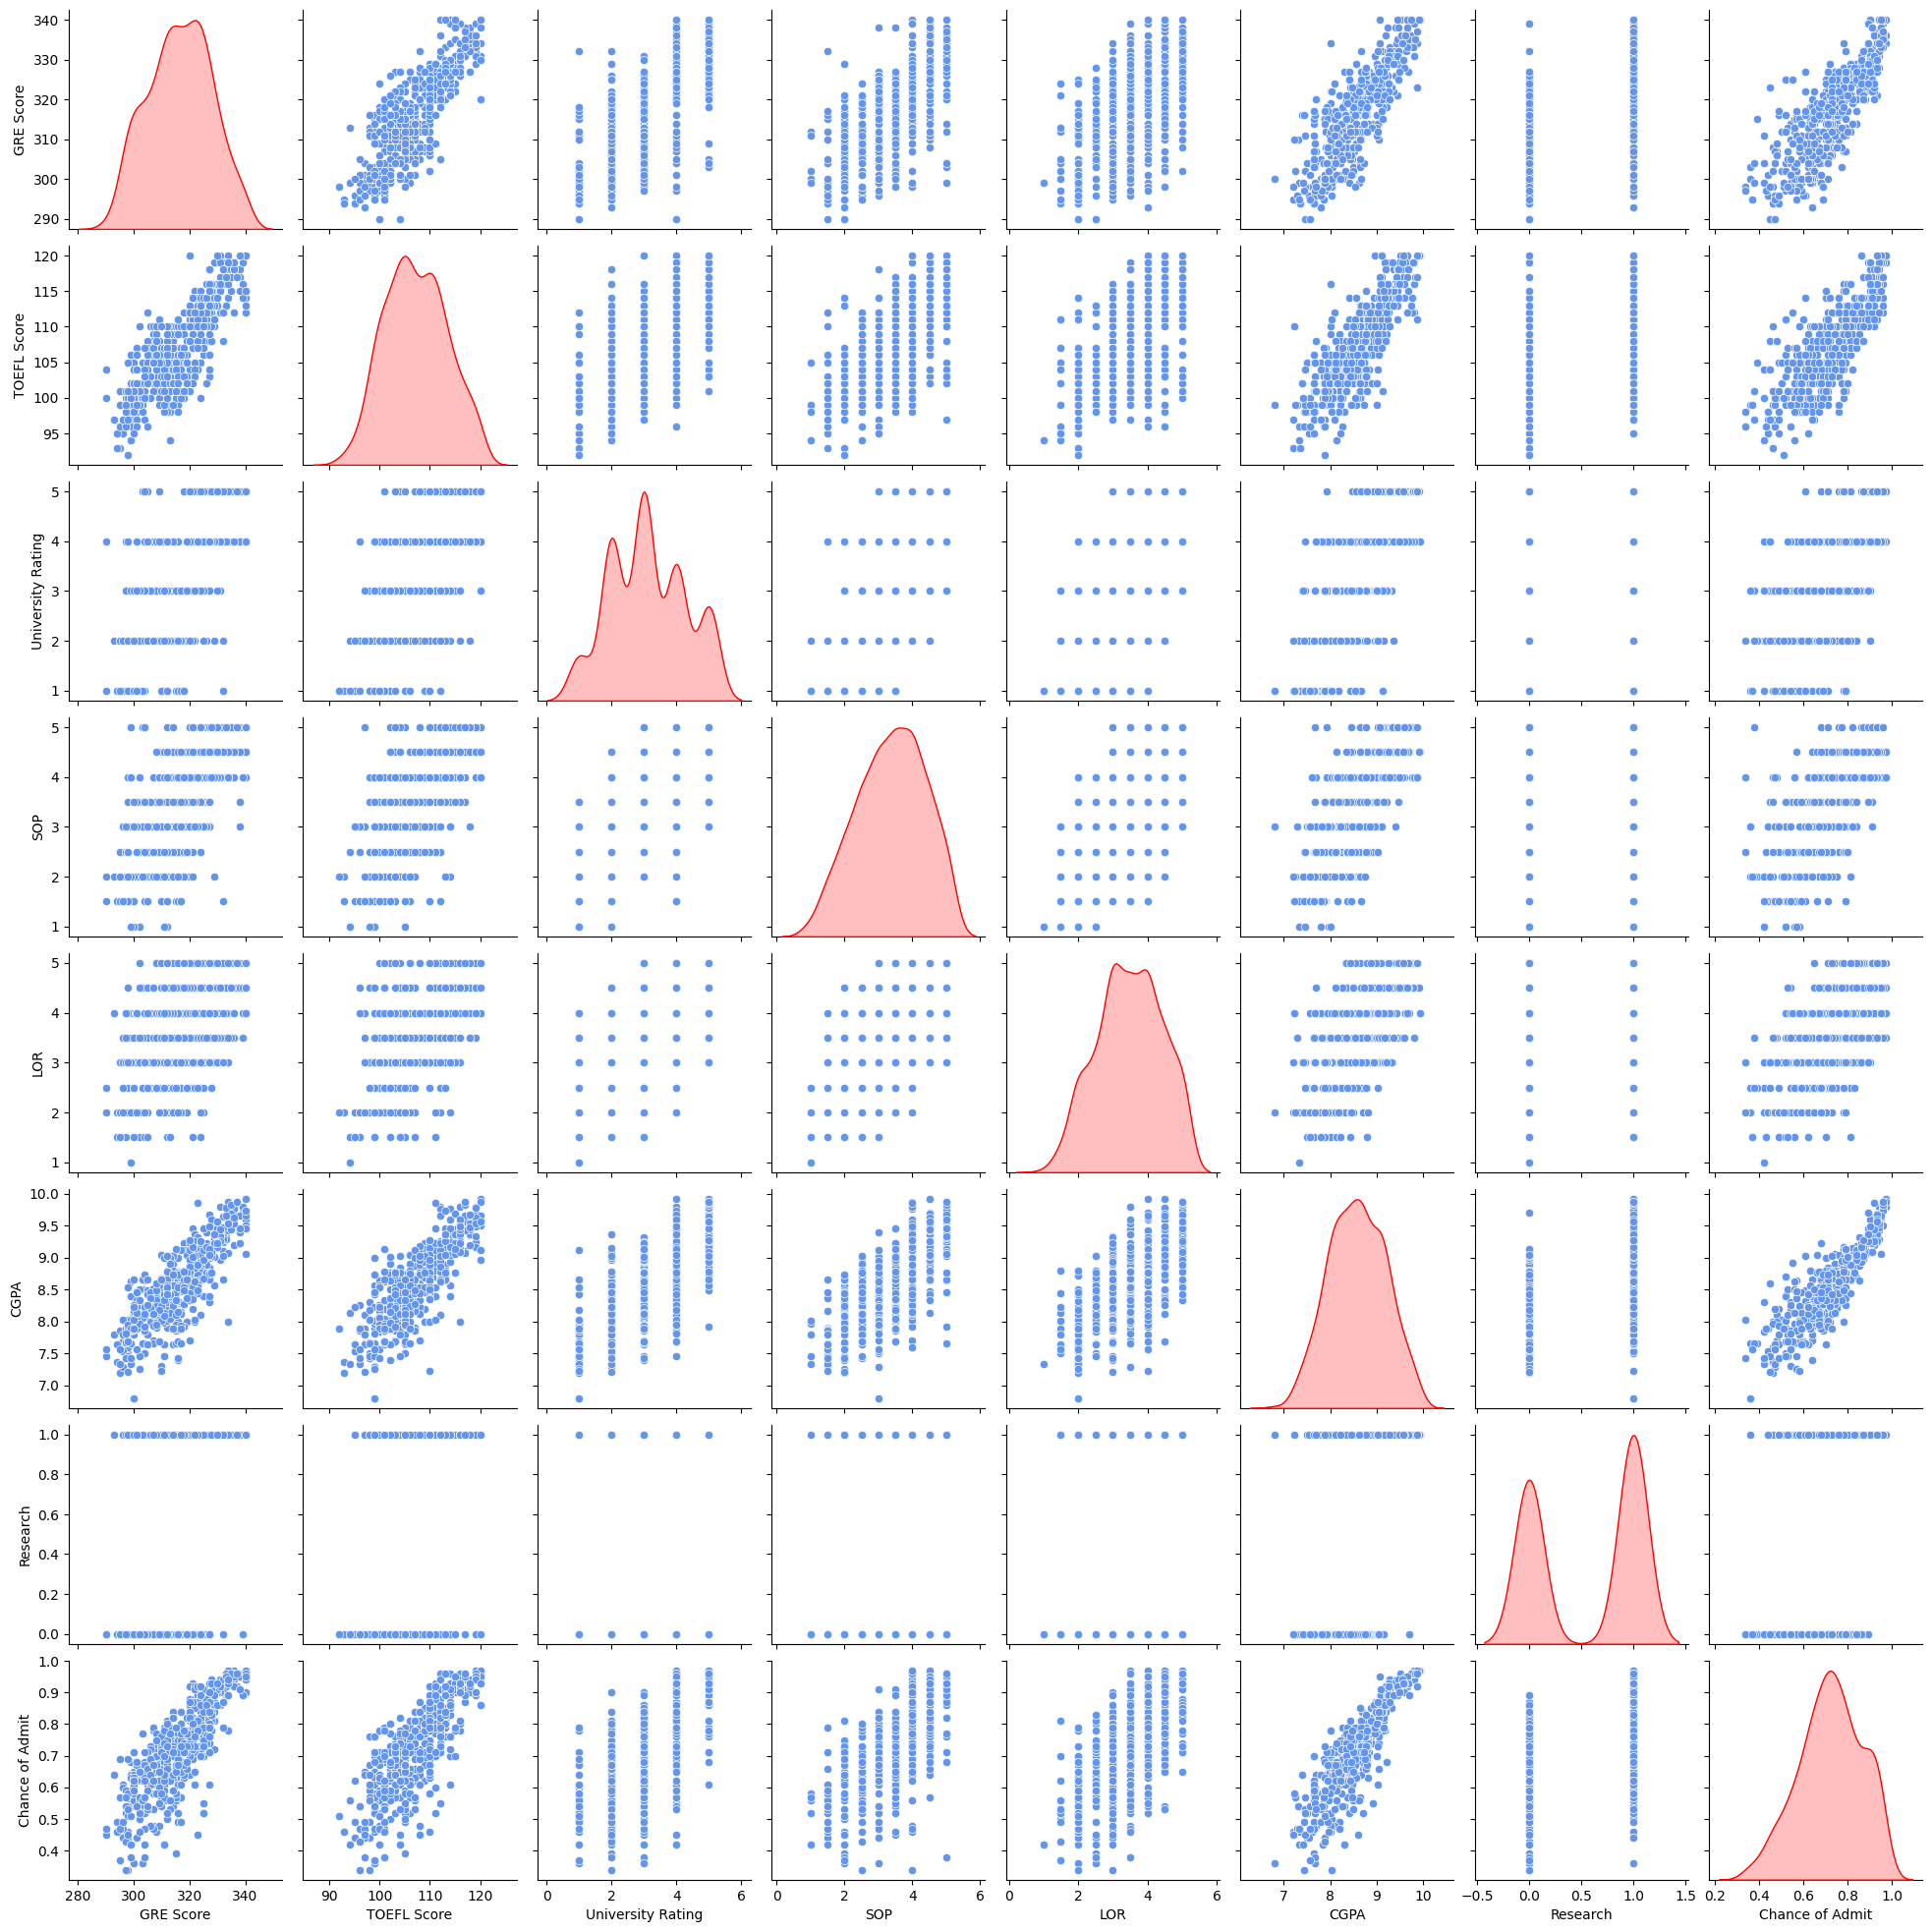

In [31]:
# visualizing the relationships between predictor numeric variables

sns.pairplot(df.select_dtypes(include='number'),diag_kind='kde',plot_kws={'color': 'cornflowerblue'},diag_kws={'color': 'red'})
plt.show()

**The Diagonal (Red Curves):** These are Kernel Density Estimate (KDE) plots. They show the distribution of a single variable, helping us see where values are most concentrated. For example, the "GRE Score" peaks around the middle of its range.

**Off-Diagonal Plots (Blue Scatterplots):** These show the relationship between two different variables.
Positive Correlation: Many of these plots (like GRE Score vs. TOEFL Score) show a clear upward trend. This means as one score goes up, the other tends to as well.

**Discrete vs. Continuous:** Notice that some plots (like those in the top rows) look like grids of dots. This indicates those variables (likely "SOP" or "LOR" ratings) are discrete or ordinal (e.g., 1, 2, 3, 4, 5). The bottom plots are more "cloud-like," suggesting continuous variables like GPA or Chance of Admit.


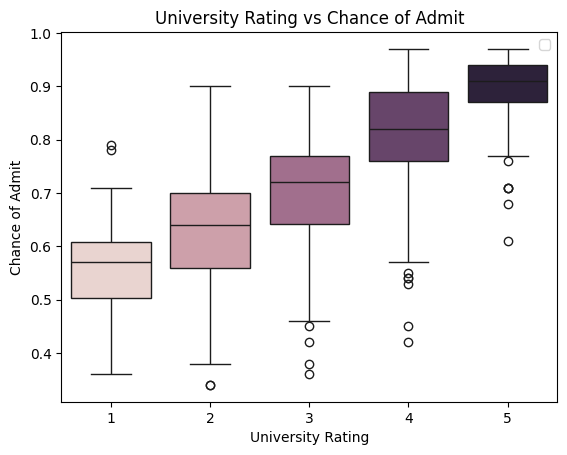

In [32]:
# impact of university rating in admission
sns.boxplot(x="University Rating", y="Chance of Admit", hue= 'University Rating',data=df)
plt.title("University Rating vs Chance of Admit")
plt.legend("")
plt.show()

###**Key Observations**

1. The box plot shows a clear positive relationship between "University Rating" and "Chance of Admit"

2. The horizontal line inside each box (the median) moves up steadily as the university rating increases. Students from higher-rated universities generally have a better chance of admission.

3. **High Outliers (Rating 1):** These are "overachievers"—students from lower-tier universities who have a much higher chance of admission than their peers (likely due to a perfect GRE or CGPA).

4. **Low Outliers (Ratings 3, 4, 5):** These are "underachievers"—students from top-tier universities who have a surprisingly low chance of admission (likely due to very poor test scores or a low GPA).


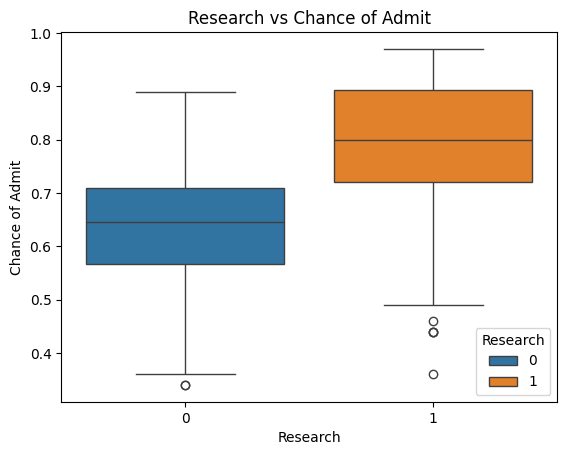

In [33]:
# impact of Research in admission
sns.boxplot(x="Research", y="Chance of Admit", hue="Research",data=df)
plt.title("Research vs Chance of Admit")
plt.show()

###**Key Observations**

1. The median "Chance of Admit" for students with research experience (1) is significantly higher (around 0.8) than those without it (0, around 0.65).

2. Notice that for the research group (1), the entire "box" (the middle 50% of students) sits almost entirely above the median of the non-research group. Having research experience effectively "lifts" your likely outcome.

3. The research group has several low-end outliers. This suggests that while research helps, it cannot rescue an application if other core factors (like high-correlation CGPA) are too low.

####**checking for multicollinearity**

**Multicollinearity** occurs when two or more independent variables in a regression model are highly correlated, allowing one variable to be accurately predicted from the others. This shared variance makes it challenging to isolate the individual impact of each variable on the dependent variable.

**The Consequences**

--> **Unreliable Coefficients:** We can't trust the "weight" assigned to each variable.

--> **Reduced Power**: It becomes harder to prove that a specific variable actually has an effect (uniterpretability)

--> **Sensitivity:** Adding or removing a single observation can completely flip the model's results.

**How to deal with multicolliniarity : Variance Inflation Factor(VIF)**

**The Variance Inflation Factor (VIF)** is a statistical metric used to ***measure the severity of multicollinearity*** in a multiple regression model. It quantifies how much the variance (and standard error) of an estimated regression coefficient is **"inflated"** due to correlation with other predictor variables.


In [34]:
# splitting the data into features and target

y = df["Chance of Admit"]
# Features (input variables)
X = df.drop("Chance of Admit",axis=1)
print("Target:", y)
print("Features:", X)

Target: 0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance of Admit, Length: 500, dtype: float64
Features:      GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research
0          337          118                  4  4.5  4.5  9.65         1
1          324          107                  4  4.0  4.5  8.87         1
2          316          104                  3  3.0  3.5  8.00         1
3          322          110                  3  3.5  2.5  8.67         1
4          314          103                  2  2.0  3.0  8.21         0
..         ...          ...                ...  ...  ...   ...       ...
495        332          108                  5  4.5  4.0  9.02         1
496        337          117                  5  5.0  5.0  9.87         1
497        330          120                  5  4.5  5.0  9.56         1
498        312          103                  4  4.0  5.0  8.43       

In [35]:
# importing variance_inflation_factor for calculating VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# importing train_test_split
from sklearn.model_selection import train_test_split

# splitting the data into traing and testing datasets before applying VIF
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [36]:
print("Training data:", X_train.shape) # this excludes target y_train
print("Testing data:", X_test.shape) # this excludes target y_test

Training data: (400, 7)
Testing data: (100, 7)


####test_size=0.2 means

--> 20% data → Testing

--> 80% data → Training

Total = 500 rows

--> Train = 400

--> Test = 100


In [37]:
# Building Linear Regression Model
import statsmodels.api as sm

# Add intercept manually().  If we don't add a constant, the model is forced to pass through the origin.
X_train_sm = sm.add_constant(X_train)

# Fit model
model = sm.OLS(y_train, X_train_sm).fit()

# Summary (this is the main advantage)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          3.41e-142
Time:                        14:29:58   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.12

R2/Adj.R2 of >0.8 indicates that the model is robust despite of not removing the outlier. The features were able to explain about 82% of the variance in admission chances.

F-statistic at 257.0 with a near-zero p-value (3.41e-142), the model is highly significant. Even with the outlier included, the relationship between the features and the "Chance of Admit" is extremely robust.


In [38]:
# checking for multicollinearity
X = X_train_sm

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

In [39]:
vif_data
# high VIF in const can be avoided as the intercept is compensating for the large avergae values (e.g : GRE score)

,feature,VIF
0,const,1683.776580
1,GRE Score,4.489983
2,TOEFL Score,3.664298
3,University Rating,2.572110
4,SOP,2.785764
5,LOR,1.977698
6,CGPA,4.654540
7,Research,1.518065


**correlation and muticollinearity tells different story !!**

Pair Plots show pairwise correlation (one variable vs. another). It is very common (and often good) for two features to have a linear relationship of, say, 0.5 or 0.6.
VIF measures multicollinearity (one variable vs. all other variables combined).

A VIF below 5 generally means that even though two variables look related in a plot, they still provide ***enough unique information*** that the model can distinguish between them.

Since the VIF is below 5 for all features, ***we don't have a multicollinearity problem that would "break" your model or make your coefficients unstable***. We have found features that are related to the target and each other in a healthy, manageable way.

This is the reason why we are getting a high Rsquared value of 0.827.  


In [40]:
# checking model coefficients
model.params

,0
const,-1.421447
GRE Score,0.002434
TOEFL Score,0.002996
University Rating,0.002569
SOP,0.001814
LOR,0.017238
CGPA,0.112527
Research,0.024027


At this juncture interpreting the coefficients does not make any sense because ***features are not scaled*** and hence on its own, a coefficient value doesn't tell us if a feature is important; it only tells the mathematical relationship based on the current units.

so we have to perform ***feature scaling*** and again fit the model to check for coefficients.

The features **'GRE Score'** and **'TOEFL Score'** are in different range compared to other features. So feature scaling is critical in ensuring  ***'level playing field'***    between features.

Without scaling, features with large ranges  create a skewed ***"error surface"*** that causes the optimization algorithm to oscillate or "zig-zag". Scaling enhances the interpretability of our final results.

When all features are standardized (e.g., mean 0, standard deviation 1), we can directly compare the magnitudes of their coefficients to determine which has the ***strongest impact*** on our prediction.

But before that lets check the distribution in order to decide on the feature scaling technique to apply.

In [41]:
# standardizing the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**why standard scalar ??**

because our data is approx normal in distribution

The StandardScaler shifts the data so that:
Mean = 0
Standard Deviation = 1

In [42]:
X_train_scaled

array([[ 0.38998634,  0.6024183 , -0.09829757, ...,  0.56498381,
         0.4150183 ,  0.89543386],
       [-0.06640493,  0.6024183 ,  0.7754586 , ...,  1.65149114,
        -0.06785154, -1.11677706],
       [-1.25302222, -0.87691722, -0.09829757, ..., -0.52152352,
        -0.13445427, -1.11677706],
       ...,
       [-1.34430047, -1.37002906, -1.8458099 , ..., -1.60803084,
        -2.2157898 , -1.11677706],
       [-0.7053527 , -0.38380538, -0.97205374, ...,  0.56498381,
        -1.49981038, -1.11677706],
       [-0.24896144, -0.21943477, -0.97205374, ...,  0.02173015,
        -0.55072138, -1.11677706]])

In [43]:
# after scaling the features

X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_train.columns)

X_train_sm = sm.add_constant(X_train_final)
X_test_sm = sm.add_constant(X_test_final)

model = sm.OLS(y_train.values, X_train_sm).fit()

# Summary (this is the main advantage)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          3.41e-142
Time:                        14:30:36   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7242      0.00

####**Model Interpretation**

1. Rsquared/Adj.Rsquared remained almost same.

2. But now the coefficients are **more interpretable** as they are scaled now.

3. strongest predictor is **'CGPA'** with a coefficient of  **0.0693**,  this tells us that for every 1 standard deviation increase in CGPA, the chance of admission jumps by nearly **7%**.

4. GRE (0.0254), TOEFL (0.0206), and LOR (0.0174): All are highly significant (P=0.000) and contribute positively.

5. Research (0.0101): Also significant (P=0.008).

6. University Rating (P = 0.570) and SOP (P = 0.824): These P-values are much higher than 0.05. Meaning in the presence of CGPA and GRE scores, the University Rating and SOP don't provide much "new" information to the model.

7. High VIF in const is reduced to 0.7 after scaling

In [44]:
# checking coefficients after scaling the features and fitting the model
model.params

,0
const,0.724175
GRE Score,0.026671
TOEFL Score,0.018226
University Rating,0.002940
SOP,0.001788
LOR,0.015866
CGPA,0.067581
Research,0.011940


In [45]:
X_train_final.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,0.389986,0.602418,-0.098298,0.126796,0.564984,0.415018,0.895434
1,-0.066405,0.602418,0.775459,0.633979,1.651491,-0.067852,-1.116777
2,-1.253022,-0.876917,-0.098298,0.126796,-0.521524,-0.134454,-1.116777
3,-0.248961,-0.055064,-0.972054,-0.887570,0.564984,-0.517420,-1.116777
4,-0.796631,-0.219435,-0.098298,0.126796,-1.064777,-0.617324,0.895434


In [46]:
X_test_final.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,1.576604,1.424271,0.775459,0.633979,0.021730,1.597217,0.895434
1,-0.248961,0.109306,0.775459,1.141162,0.564984,0.764683,0.895434
2,-0.157683,-0.383805,-0.972054,-1.394754,-1.064777,-1.549762,-1.116777
3,-0.431518,0.273677,-0.098298,-0.380387,-0.521524,0.181909,-1.116777
4,0.846378,0.766789,-0.098298,0.126796,-0.521524,0.781333,0.895434


In [47]:
# dropping the columns with high p-values (irrelevant features) from training set and test set

X_train_final.drop(columns=['University Rating', 'SOP'],axis=1, inplace=True)
X_test_final.drop(columns=['University Rating', 'SOP'],axis=1, inplace=True)

In [48]:
# training the model again after removing features

X_train_sm = sm.add_constant(X_train_final)
X_test_sm = sm.add_constant(X_test_final)

model = sm.OLS(y_train.values, X_train_sm).fit()

# Summary (this is the main advantage)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     360.8
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          1.36e-144
Time:                        14:31:01   Log-Likelihood:                 561.54
No. Observations:                 400   AIC:                            -1111.
Df Residuals:                     394   BIC:                            -1087.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.7242      0.003    241.830      

The coefficients of all features improved after removing the irrelevant features from the dataset

####earlier

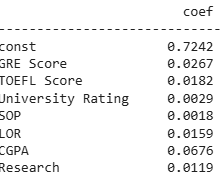

####latest

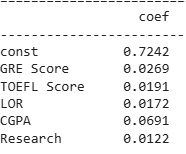

####pvalues

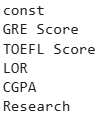 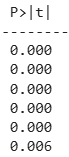

most of features has **P > |t| = 0.000** which means that the feature is highly statistically significant.

Specifically, it means the probability that the relationship between that feature and the target (Chance of Admit) happened by pure random chance is essentially zero.

 Features with low p-values (typically < 0.05) are the ones we definitely want to keep in our model because they provide **"predictive power."**

In [49]:
# testing the model

X_test_sm = X_test_sm[X_train_sm.columns]

y_pred = model.predict(X_test_sm)

In [50]:
y_pred

,0
0,0.915400
1,0.793055
2,0.573592
3,0.707741
4,0.817513
...,...
95,0.436098
96,0.683978
97,0.793500
98,0.742302


In [51]:
#  model performance evaluation : The Loss Function
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# checking adjusted_R2
n = len(y_test)       # Number of observations
p = X_test_final.shape[1]    # Number of predictors (5)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)


In [52]:
# checking test metrics
test_metrics = pd.DataFrame({'MAE':mae,"RMSE":rmse,"R2_Score":r2,"Adj_R2":adj_r2},index=['Model Performance']).T
test_metrics

,Model Performance
MAE,0.042923
RMSE,0.061425
R2_Score,0.815500
Adj_R2,0.805686


####**train_metrics**
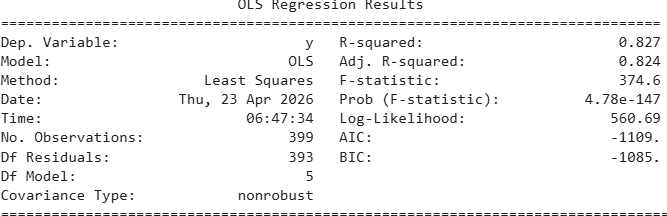

As seen, there is drop in the test_metrics compared to train_metrics. This can be attributed to ***'overfitting'***.  It means the model has ***"memorised"*** the specific patterns and random noise in the training data rather than learning general relationships that apply to new, unseen data.

we can fix this by aplying regularization techniques like Ridge/Lasso Regression on train_data to to shrink the coefficients, which **"smooths out"** the model and helps it generalise better. Lasso Regression is not useful as we do not have features with less significance as seen with p-values

Regularization is the process of adding a penalty term to the objective function (the Loss Function) to control bias-variance trade-off or balance between overfitting and underfitting. It also handles multicollinearity between features well.

In [53]:
from sklearn.linear_model import Lasso, Ridge

lasso_model = Lasso(alpha=0.01)  # Alpha is the regularization strength
ridge_model = Ridge(alpha=1.0)

lasso_model.fit(X_train_final, y_train)
ridge_model.fit(X_train_final, y_train)

Ridge()

In [54]:
# comparison table for Lasso/Ridge
coef_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Lasso Coef': lasso_model.coef_,
    'Ridge Coef': ridge_model.coef_
})

coef_df

,Feature,Lasso Coef,Ridge Coef
0,GRE Score,0.026321,0.027014
1,TOEFL Score,0.015302,0.019280
2,LOR,0.011345,0.017309
3,CGPA,0.069224,0.068570
4,Research,0.006167,0.012248


####**Key Observations:**

1.none of the Lasso coefficients are zero. It suggests that every feature contains unique, useful information that the model doesn't want to throw away.

2. Ridge coefficients are slightly higher than the Lasso ones for almost every feature (except CGPA). this is because Ridge is more "conservative," spreading the importance across all variables.

3. The model is giving GRE Score (approx 0.026) about twice as much "weight" as TOEFL Score (approx 0.015). This suggests that while both matter, the GRE is a slightly more influential factor in the admission decision for this specific dataset.

4. CGPA has the highest coefficient in both models (~0.069). A small increase in CGPA has a much bigger impact on the "Chance of Admit" than a small increase in GRE or TOEFL scores.


In [55]:
# testing the model
lasso_predictions = lasso_model.predict(X_test_final)
ridge_predictions = ridge_model.predict(X_test_final)

In [56]:
print('test MSE for L1:', mean_squared_error(y_test, lasso_predictions))
print('test MSE for L2:', mean_squared_error(y_test, ridge_predictions))

test MSE for L1: 0.0038203247528045357
test MSE for L2: 0.0037770066475508435


The L2 (Ridge) model has a slightly lower MSE (0.00377) compared to L1 (Lasso) (0.00382).

This suggests that keeping all features (GRE, TOEFL, CGPA, etc.) and just slightly "shrinking" them works better than Lasso’s attempt to simplify the model.

In [57]:
# checking the test metrics
mse = mean_squared_error(y_test, ridge_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, ridge_predictions)
r2 = r2_score(y_test, ridge_predictions)

# checking adjusted_R2
n = len(y_test)       # Number of observations
p = X_test_final.shape[1]    # Number of predictors (5)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [58]:
test_metrics_ridge = pd.DataFrame({'MAE':mae,"RMSE":rmse,"R2_Score":r2,"Adj_R2":adj_r2},index=['Model Performance']).T
test_metrics_ridge

,Model Performance
MAE,0.042963
RMSE,0.061457
R2_Score,0.815305
Adj_R2,0.805481


In [59]:
mse = mean_squared_error(y_test, lasso_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, lasso_predictions)
r2 = r2_score(y_test, ridge_predictions)

# checking adjusted_R2
n = len(y_test)       # Number of observations
p = X_test_final.shape[1]    # Number of predictors (5)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [60]:
test_metrics_lasso = pd.DataFrame({'MAE':mae,"RMSE":rmse,"R2_Score":r2,"Adj_R2":adj_r2},index=['Model Performance']).T
test_metrics_lasso

,Model Performance
MAE,0.042790
RMSE,0.061809
R2_Score,0.815305
Adj_R2,0.805481


###**Testing the assumptions of the linear regression model**

####**1. Multicollinearity check by VIF score**

Already checked and found that none of the features have VIF >5 indicating that features have less mutilcollinearity between them and contributing significantly in predicting the chance of admission.

Also regularization applied before handles multicollinearity.

####**2. The mean of residuals is nearly zero**

In [61]:
# checking mean of residuals in ridge_prediction
residuals = y_test.values.reshape(-1, 1) - ridge_predictions.reshape(-1, 1)
mean_residuals = np.mean(residuals)
mean_residuals

np.float64(-0.005290886448400378)

 On average, the predictions are 0.005 higher than the actual values (since residual = actual - predicted).

However, on a scale of 0 to 1, a bias of 0.5% is negligible.

In a perfect linear regression model, the mean of residuals should be exactly 0.

####**3. Test for homoscedasticity**

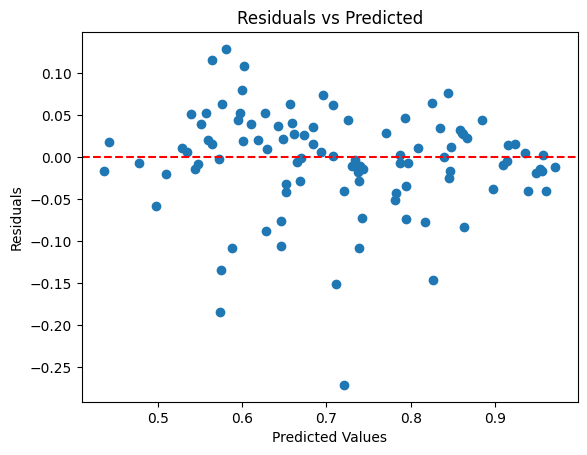

In [62]:
# checking homoscedasticity

plt.scatter(ridge_predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()


####**Key Observations:**

**Homoscedasticity:** The points are fairly evenly spread above and below the red line (the zero-error line). There is no obvious "funnel" shape (where the error gets much larger as the predicted value increases), which means your model is equally reliable for both low-chance and high-chance candidates.

**No Clear Pattern:** The dots look like a random cloud. There is no such "U" shape or a curve which would mean we missed a non-linear relationship (like a squared feature). Since it's random, our linear assumption is correct.

**Scale of Error:** Notice the Y-axis. Most residuals are between -0.10 and +0.10. For a target variable that goes from 0 to 1, having an error within 10% for the vast majority of cases is excellent.

**The "Lower" Outliers:** We have a few points dipping down toward -0.20 and -0.25 (around the 0.6 to 0.7 predicted range). These are students where the ***model overestimated their chances***—likely candidates with great scores who were rejected for some reason not captured in the data.

**Tightening at the Top:** Notice how the cloud gets a bit "thinner" as you approach a predicted value of 1.0. This makes sense; there is less room for error when a student is nearly guaranteed admission.


####**4. Linearity of variables**

The assumption of linearity is satisfied as the residual plot exhibits a random distribution of errors around the zero-line with no observable patterns.

####**5. Normality of residuals**

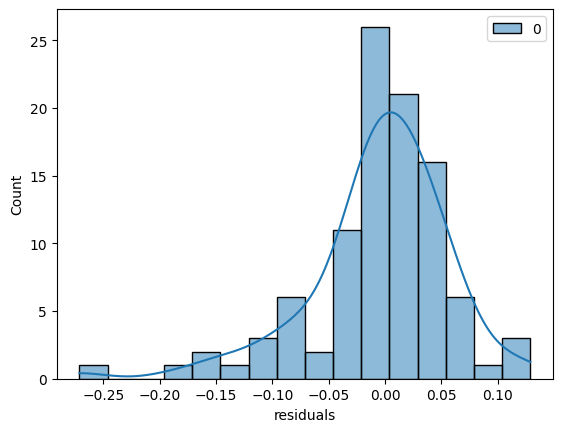

In [63]:
sns.histplot(residuals,kde=True)
plt.xlabel('residuals')
plt.show()

The blue line (KDE) shows a clear bell-shaped curve centered very close to 0.00.  It means that most of your errors are tiny (close to zero), and large errors are rare.

We have a few cases where the ***model overestimated***  the chance of admission by a significant amount (e.g., the student had great stats but didn't get in)

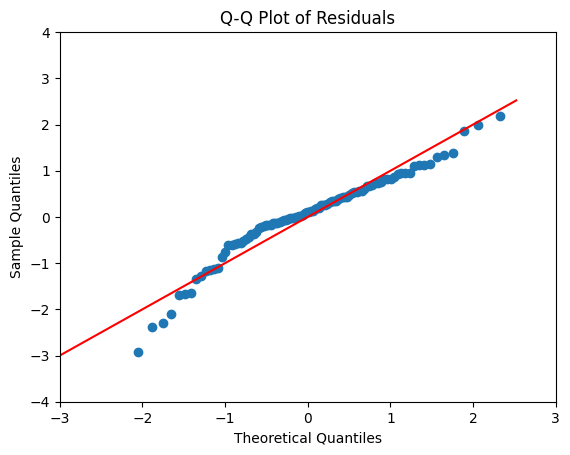

In [64]:
# checking normality of residuals with qq-plot
sm.qqplot(residuals.flatten(), line='45', fit=True)

plt.title('Q-Q Plot of Residuals')
plt.xlim([-3, 3])
plt.ylim([-4, 4])
plt.show()

Most of the points (between -1 and +2 on the X-axis) follow the red line very closely. This means for the vast majority of applicants, the model’s errors are perfectly normally distributed. This validates using a linear model like Ridge.

**Negative Outliers:** These are cases where the actual chance of admission was much lower than the model predicted.

In university admissions, some students have "perfect" stats but get rejected due to factors not captured by the data

###**Key Insights & Recommendations**

1. All the features influenced positively in predicting the chance of admission.  With VIF below 5 and p_values < 0.05 proves statisitcl significance of these features. Most of the predictor variables has correlation with eachother (good for linear regression) but not to the extent of mutilcollinearity which makes some features redundant.

2. Model with Ridge regularization achieved R2 score/Adj.R2 Score > 0.8 in both train and test, means the model was able to explain over 80% of the variance in admission chances.

3. test MSE for L2/Ridge: 0.0037 which means model’s predictions are, on average, only 6.1% (RMSE = 0.061) away from the actual "Chance of Admit" value. Since the target variable (Chance of Admit) ranges from 0 to 1, an error of 0.06 is very small. For example, if a student's real chance is 0.80, the model is likely to predict somewhere between 0.74 and 0.86.

4. CGPA is the top contributor in deciding the chance of admission. Students with good CGPA had a greater chance of getting the admission than other factors like GRE Scoes & TOEFL Scores.

5. There are students with good scores but rejected due to some other factors not captured by the data. This suggests that high scores do not guarantee a 1.0 chance of admission. In such cases model becomes **"too optimistic"** and give a higher probability for admission. It is recommended that either the size of th dataset may be increased vertically and horizontally for better understanding of the hidden non-linear relationships between the features.

6. Assumptions of linear regression like homoscedasticity,means of residuals, linearity of variables where passed however some outliers like "highscore but rejected" distorted the otherwise normal distribution of the residuals (QQplot).

7. It is recommended that features like Work Experience / Internships, diversity metrics, financial factors may be included to capture the qualitative and contextual parts of an application.

8. The above recommendations can significantly improve models performance in predicting the chance of admission with low margin of error.


